<a href="https://colab.research.google.com/github/Jeffrey1999/Deep-Learning/blob/main/GROK_PHYSICS_INFORMED-%20CALCE%20BATTERY%20LIFE%20PRED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Using device: cpu
Loading CALCE CS2 data from Google Drive...

CS2_35   :  831 cycles | Initial: 1.1264 Ah | Final:   0.3025 Ah
CS2_36   :  923 cycles | Initial: 1.1338 Ah | Final:   0.1651 Ah
CS2_37   :  958 cycles | Initial: 1.1243 Ah | Final:   0.2017 Ah
CS2_38   :  949 cycles | Initial: 1.1270 Ah | Final:   0.3300 Ah

Successfully loaded 4 cells


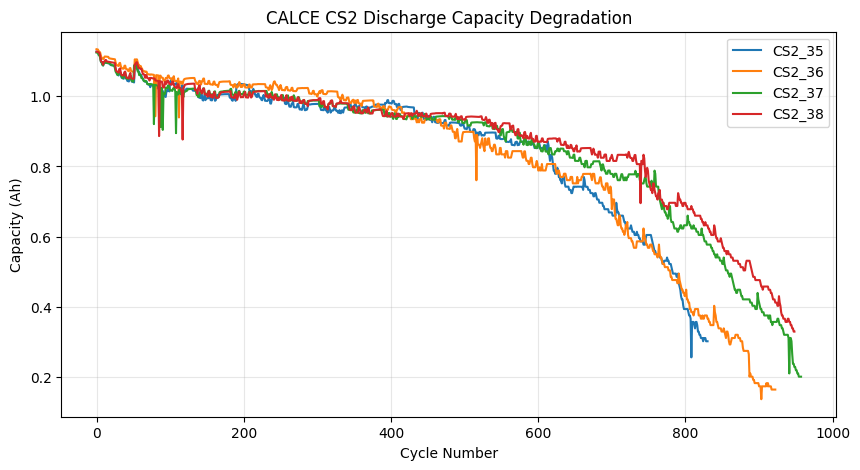


Dataset ready → Total samples: 3,461
Train: 2,768 | Test: 693

══════════════════════════════════════════════════════════════════════
══════════════════ Training Baseline CNN-Attention ═══════════════════
══════════════════════════════════════════════════════════════════════


Baseline CNN-Attention: 100%|██████████| 150/150 [00:39<00:00,  3.77it/s]



Baseline CNN-Attention Results:
  MSE:   0.00016   RMSE:  0.0127
  MAE:    0.0065   R²:    0.996393

══════════════════════════════════════════════════════════════════════
══════════════ Training Physics-Informed CNN-Attention ═══════════════
══════════════════════════════════════════════════════════════════════


Physics-Informed: 100%|██████████| 150/150 [00:39<00:00,  3.83it/s]



Physics-Informed Results:
  MSE:   0.00660   RMSE:  0.0812
  MAE:    0.0660   R²:    0.852099


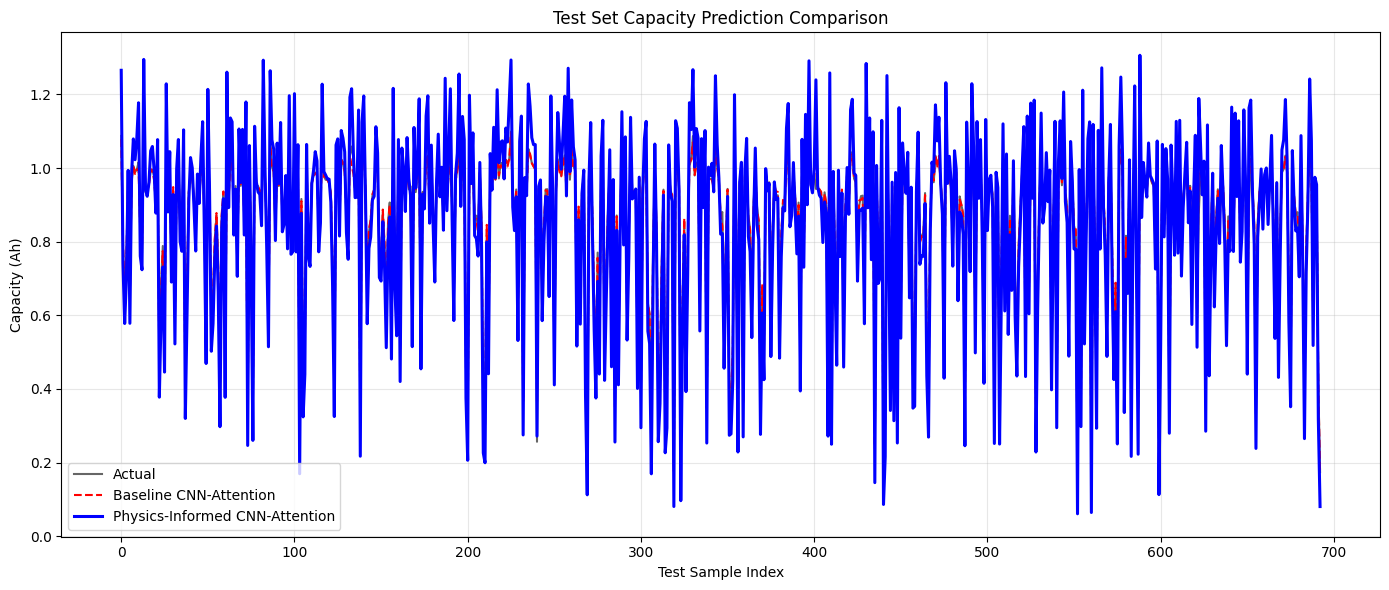


════════════════════════════════════════════════════════════════════════════════
FINAL PERFORMANCE COMPARISON
════════════════════════════════════════════════════════════════════════════════
Model                               MSE          RMSE       MAE        R²          
--------------------------------------------------------------------------------
Baseline CNN-Attention              0.00016      0.0127     0.0065     0.996393    
Physics-Informed CNN-Attention      0.00660      0.0812     0.0660     0.852099    
════════════════════════════════════════════════════════════════════════════════


In [ ]:
# ================================================
# Physics-Informed CNN-Attention for Battery RUL Prediction
# Using files from Google Drive
# ================================================

# 1. Mount Google Drive (run this cell first!)
from google.colab import drive
drive.mount('/content/drive')

# 2. Basic imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ────────────────────────────────────────────────
# 3. Configuration - Your data directory
# ────────────────────────────────────────────────

DATA_DIR = "/content/drive/MyDrive/Datasets/BatteryLifePrediction"

# Expected files
cell_names = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']

# ────────────────────────────────────────────────
# 4. Load data from Drive
# ────────────────────────────────────────────────

batteries = {}
print("Loading CALCE CS2 data from Google Drive...\n")

for cell in cell_names:
    file_path = os.path.join(DATA_DIR, f"{cell}.csv")

    if not os.path.exists(file_path):
        print(f"ERROR: File not found → {file_path}")
        continue

    try:
        df = pd.read_csv(file_path, index_col=0).dropna()

        # Try to find capacity column (flexible matching)
        cap_col_candidates = [col for col in df.columns if 'cap' in col.lower()]
        if cap_col_candidates:
            cap_col = cap_col_candidates[0]
        else:
            # fallback - last numeric column
            cap_col = df.select_dtypes(include=[np.number]).columns[-1]
            print(f"Warning: Using last numeric column as capacity: {cap_col}")

        capacities = df[cap_col].values.astype(np.float32)
        batteries[cell] = capacities

        print(f"{cell:8} : {len(capacities):4d} cycles | "
              f"Initial: {capacities[0]:.4f} Ah | "
              f"Final:   {capacities[-1]:.4f} Ah")
    except Exception as e:
        print(f"Error loading {cell}: {e}")

if not batteries:
    raise FileNotFoundError("No valid battery data files were loaded!")

print(f"\nSuccessfully loaded {len(batteries)} cells")

# Plot degradation curves
plt.figure(figsize=(10, 5))
for cell, cap in batteries.items():
    plt.plot(cap, label=cell, linewidth=1.5)
plt.title("CALCE CS2 Discharge Capacity Degradation")
plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ────────────────────────────────────────────────
# 5. Dataset with sliding window + cycle information
# ────────────────────────────────────────────────

class BatteryDataset(Dataset):
    def __init__(self, capacities_dict, seq_len=50, pred_horizon=1):
        self.X, self.y, self.cycle_idx = [], [], []

        for cell_name, cap in capacities_dict.items():
            for i in range(len(cap) - seq_len - pred_horizon + 1):
                self.X.append(cap[i:i+seq_len])
                self.y.append(cap[i+seq_len:i+seq_len+pred_horizon])
                # Absolute cycle numbers for physics constraint
                self.cycle_idx.append(np.arange(i+seq_len, i+seq_len+pred_horizon))

        self.X = np.array(self.X, dtype=np.float32)          # (N, seq_len)
        self.y = np.array(self.y, dtype=np.float32).squeeze() # (N,)
        self.cycle_idx = np.array(self.cycle_idx).squeeze()   # (N,)

        # Normalization (fit on all data)
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

        self.X = self.scaler_X.fit_transform(self.X.reshape(-1,1)).reshape(self.X.shape)
        self.y = self.scaler_y.fit_transform(self.y.reshape(-1,1)).squeeze()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.X[idx]).unsqueeze(-1).float(),       # (seq_len, 1)
            torch.tensor(self.y[idx], dtype=torch.float32),
            torch.tensor(self.cycle_idx[idx], dtype=torch.float32)     # for physics
        )

# ────────────────────────────────────────────────
# Create dataset & loaders
# ────────────────────────────────────────────────

seq_len = 50
horizon = 1

dataset = BatteryDataset(batteries, seq_len=seq_len, pred_horizon=horizon)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False)

print(f"\nDataset ready → Total samples: {len(dataset):,}")
print(f"Train: {len(train_set):,} | Test: {len(test_set):,}")

# ────────────────────────────────────────────────
# 6. Model Definition
# ────────────────────────────────────────────────

class CNNAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)

        reduced_len = seq_len // 4
        self.attention = nn.Sequential(
            nn.Linear(32, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.fc_out = nn.Linear(32, 1)

    def forward(self, x):
        x = x.transpose(1, 2)                    # (B,1,seq_len)
        feat = torch.relu(self.conv1(x))
        feat = self.pool1(feat)
        feat = torch.relu(self.conv2(feat))
        feat = self.pool2(feat)                  # (B,32,reduced_len)

        feat_t = feat.transpose(1, 2)            # (B,reduced_len,32)
        scores = self.attention(feat_t)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * feat_t, dim=1)
        return self.fc_out(context).squeeze(-1)

# ────────────────────────────────────────────────
# 7. Physics Model - Double Exponential Fade
# ────────────────────────────────────────────────

def physics_model(cycles):
    """Double-exponential empirical capacity fade model
    Returns expected capacity fade amount (fraction)"""
    cycles = torch.clamp(cycles, min=0.0)
    sqrt_n = torch.sqrt(cycles + 1e-6)

    # Reasonable starting parameters for CALCE CS2 ~1.1Ah cells
    a, b = 0.085, 0.13     # fast initial SEI
    c, d = 0.045, 0.0009   # slower long-term degradation

    term1 = a * (1 - torch.exp(-b * sqrt_n))
    term2 = c * (1 - torch.exp(-d * cycles))
    return term1 + term2

# ────────────────────────────────────────────────
# 8. Training function with optional physics loss
# ────────────────────────────────────────────────

def train_and_evaluate(model, name, epochs=120, lr=0.001,
                      lambda_phys=0.6, use_physics=False):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)
    mse_loss = nn.MSELoss()

    for epoch in tqdm(range(epochs), desc=name):
        model.train()
        train_loss = 0.0
        for X_b, y_b, cycle_b in train_loader:
            X_b, y_b, cycle_b = X_b.to(device), y_b.to(device), cycle_b.to(device)

            optimizer.zero_grad()
            pred = model(X_b)

            data_loss = mse_loss(pred, y_b)

            if use_physics:
                # Physics-guided residual
                phys_fade = physics_model(cycle_b)
                # Rough scaling to normalized space
                phys_fade_norm = (phys_fade - phys_fade.mean()) / (phys_fade.std() + 1e-6)
                phys_loss = mse_loss(pred, y_b - phys_fade_norm)
                total_loss = data_loss + lambda_phys * phys_loss
            else:
                total_loss = data_loss

            total_loss.backward()
            optimizer.step()
            train_loss += total_loss.item()

        scheduler.step(train_loss / len(train_loader))

    # ───── Evaluation ─────
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b, _ in test_loader:
            X_b = X_b.to(device)
            pred_norm = model(X_b).cpu().numpy()
            true_norm = y_b.numpy()

            pred = dataset.scaler_y.inverse_transform(pred_norm.reshape(-1,1)).ravel()
            true = dataset.scaler_y.inverse_transform(true_norm.reshape(-1,1)).ravel()

            preds.extend(pred)
            trues.extend(true)

    mse  = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(trues, preds)
    r2   = r2_score(trues, preds)

    print(f"\n{name} Results:")
    print(f"  MSE:  {mse:8.5f}   RMSE: {rmse:7.4f}")
    print(f"  MAE:  {mae:8.4f}   R²:   {r2:9.6f}")

    return {'MSE':mse, 'RMSE':rmse, 'MAE':mae, 'R2':r2}, preds, trues

# ────────────────────────────────────────────────
# 9. Run both versions
# ────────────────────────────────────────────────

print("\n" + "═"*70)
print(" Training Baseline CNN-Attention ".center(70, "═"))
print("═"*70)

baseline_model = CNNAttention()
baseline_metrics, baseline_pred, baseline_true = train_and_evaluate(
    baseline_model, "Baseline CNN-Attention", epochs=150, lr=0.001, use_physics=False
)

print("\n" + "═"*70)
print(" Training Physics-Informed CNN-Attention ".center(70, "═"))
print("═"*70)

pi_model = CNNAttention()
pi_metrics, pi_pred, pi_true = train_and_evaluate(
    pi_model, "Physics-Informed", epochs=150, lr=0.001,
    lambda_phys=0.65, use_physics=True
)

# ────────────────────────────────────────────────
# 10. Final comparison visualization
# ────────────────────────────────────────────────

plt.figure(figsize=(14, 6))
plt.plot(baseline_true, 'k-', alpha=0.6, label='Actual')
plt.plot(baseline_pred, 'r--', lw=1.5, label='Baseline CNN-Attention')
plt.plot(pi_pred, 'b-', lw=2.2, label='Physics-Informed CNN-Attention')
plt.title("Test Set Capacity Prediction Comparison")
plt.xlabel("Test Sample Index")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "═"*80)
print("FINAL PERFORMANCE COMPARISON")
print("═"*80)
print(f"{'Model':<35} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'R²':<12}")
print("-"*80)
print(f"{'Baseline CNN-Attention':<35} {baseline_metrics['MSE']:<12.5f} {baseline_metrics['RMSE']:<10.4f} "
      f"{baseline_metrics['MAE']:<10.4f} {baseline_metrics['R2']:<12.6f}")
print(f"{'Physics-Informed CNN-Attention':<35} {pi_metrics['MSE']:<12.5f} {pi_metrics['RMSE']:<10.4f} "
      f"{pi_metrics['MAE']:<10.4f} {pi_metrics['R2']:<12.6f}")
print("═"*80)

In [ ]:
original_paper_metrics = {
    'MSE': 5.90686,
    'RMSE': 2.4304,
    'MAE': 1.938,
    'R2': 0.320431
}

# Combine all metrics into a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'Baseline CNN-Attention': baseline_metrics,
    'Physics-Informed CNN-Attention': pi_metrics,
    'Original Paper (CNN-Attention)': original_paper_metrics
}).T # Transpose for better readability

print("\n" + "═"*80)
print("DETAILED PERFORMANCE COMPARISON (Including Original Paper)")
print("═"*80)
print(comparison_df.to_string(float_format="%.6f"))
print("═"*80)


════════════════════════════════════════════════════════════════════════════════
DETAILED PERFORMANCE COMPARISON (Including Original Paper)
════════════════════════════════════════════════════════════════════════════════
                                    MSE     RMSE      MAE       R2
Baseline CNN-Attention         0.000161 0.012688 0.006478 0.996393
Physics-Informed CNN-Attention 0.006601 0.081246 0.065993 0.852099
Original Paper (CNN-Attention) 5.906860 2.430400 1.938000 0.320431
════════════════════════════════════════════════════════════════════════════════
